# Phase 4 — Robustness Audit (Stylistic vs Discourse-level CIV)

This phase is the diagnostic core of the project. Both scoring models (BERT and Longformer) are exposed to the six verified perturbations, and their score responses are measured. The question is not which model scores higher, but *what each model is sensitive to* — surface style, or argument structure.

**Framework logic**

The six perturbations fall into three groups with different expected behaviour:

- **Stylistic CIV — P1 (lexical formality), P2 (connective density), P3 (syntactic voice).** These preserve meaning (high SBERT similarity). A model that scores for the right reasons should barely move. A large shift here is evidence of construct-irrelevant variance — the model reacting to surface form.
- **Discourse-level CIV — P4 (discourse weakening), P5 (structural disruption).** These deliberately weaken the argument (an Effective segment replaced by an Ineffective one; a Counterclaim or Rebuttal removed). Here a shift is *expected and correct* — a downward shift shows the model is responding to argument quality rather than surface text.
- **Length counterfactual — P6 (length extension).** Filler sentences repeat existing points without adding argument, holding quality roughly constant while increasing length. If the predicted score *rises*, that is the counterfactual evidence required before making any length-related claim.

**Metrics per perturbation, per model**

- **MAS (Mean Absolute Shift)** — average absolute change in the continuous predicted score, `mean(|score_perturbed − score_original|)`. Magnitude of sensitivity.
- **Signed shift** — average `score_perturbed − score_original`. Direction of sensitivity (does the score go up or down).
- **Band-change rate** — fraction of essays whose rounded 1–6 score changed. An interpretable, human-facing view.

All scoring reuses each model's exact training-time configuration, so the audit reflects the models as trained.

## 1. Environment

Requires a GPU session, the verified perturbation dataset, and both trained checkpoints attached as inputs.

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from transformers import BertModel, BertTokenizerFast
from transformers import LongformerModel, LongformerTokenizerFast
from transformers import logging as hf_logging
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
if device.type == 'cuda':
    print("GPU   :", torch.cuda.get_device_name(0))

Device: cuda
GPU   : Tesla T4


In [4]:
import glob; [print(p) for p in glob.glob('/kaggle/input/**/*', recursive=True) if p.endswith(('.csv','.pt'))]

/kaggle/input/datasets/shravaniuk/phase4-robustness/best_bert_aes_model.pt
/kaggle/input/datasets/shravaniuk/phase4-robustness/best_longformer_aes_model.pt
/kaggle/input/datasets/shravaniuk/phase4-robustness/perturbations_verified.csv


[None, None, None]

## 2. Load the verified perturbation set

The audit runs on all essays that passed each perturbation's semantic gate. Working entirely inside `perturbations_verified.csv` keeps a single consistent essay set and avoids any cross-file ID joins. Each perturbation is mapped to its text column and its gate flag.

In [5]:
PERT_PATH = '/kaggle/input/datasets/shravaniuk/phase4-robustness/perturbations_verified.csv'   
df = pd.read_csv(PERT_PATH, dtype={'essay_id': str})
print("Essays:", len(df))

# Map each perturbation to (perturbed_text_column, gate_flag_column)
PERTURBATIONS = {
    'P1_lexical_formality'  : ('p1_formality',  'gate_p1'),
    'P2_connective_density' : ('p2_density',    'gate_p2'),
    'P3_syntactic_voice'    : ('p3_voice',      'gate_p3'),
    'P4_discourse_weakening': ('p4_weakening',  'gate_p4'),
    'P5_structural_disrupt' : ('p5_disruption', 'gate_p5'),
    'P6_length_extension'   : ('p6_length',     'gate_p6'),
}
STYLISTIC = ['P1_lexical_formality', 'P2_connective_density', 'P3_syntactic_voice']
DISCOURSE = ['P4_discourse_weakening', 'P5_structural_disrupt']

for name, (col, gate) in PERTURBATIONS.items():
    n = int((df[gate] == True).sum())
    print(f"{name:26s} gated essays: {n}")

Essays: 15594
P1_lexical_formality       gated essays: 15368
P2_connective_density      gated essays: 15456
P3_syntactic_voice         gated essays: 12224
P4_discourse_weakening     gated essays: 1595
P5_structural_disrupt      gated essays: 3926
P6_length_extension        gated essays: 15456


## 3. Model definitions and score functions

The two scorer classes are identical to those used in Phases 2 and 2b. BERT uses the same head-and-tail tokenisation it was trained with (512 tokens); Longformer uses full-sequence encoding at 1024 tokens with global attention on the leading token. Both denormalise predictions with `score = pred × 5 + 1`, clipped to `[1, 6]`. Predictions are kept **continuous** (not rounded) so that small, genuine shifts are not lost.

In [6]:
class BERTEssayScorer(nn.Module):
    def __init__(self, name='bert-base-uncased', dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained(name)
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Linear(self.bert.config.hidden_size, 1)
    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.regressor(self.dropout(out.last_hidden_state[:, 0, :])).squeeze(-1)


class LongformerEssayScorer(nn.Module):
    def __init__(self, name='allenai/longformer-base-4096', dropout=0.3):
        super().__init__()
        self.longformer = LongformerModel.from_pretrained(name)
        self.dropout = nn.Dropout(dropout)
        self.regressor = nn.Linear(self.longformer.config.hidden_size, 1)
    def forward(self, input_ids, attention_mask, global_attention_mask):
        out = self.longformer(input_ids=input_ids, attention_mask=attention_mask,
                              global_attention_mask=global_attention_mask)
        return self.regressor(self.dropout(out.last_hidden_state[:, 0, :])).squeeze(-1)


def head_tail_encode(text, tok, max_len=512, head=128):
    tail = max_len - head
    ids = tok.encode(str(text), add_special_tokens=False, truncation=False)
    if len(ids) <= max_len - 2:
        enc = tok(str(text), max_length=max_len, padding='max_length',
                  truncation=True, return_tensors='pt')
        return enc['input_ids'].squeeze(0), enc['attention_mask'].squeeze(0)
    combined = ids[:head - 1] + ids[-(tail - 1):]
    input_ids = [tok.cls_token_id] + combined + [tok.sep_token_id]
    pad = [tok.pad_token_id] * (max_len - len(input_ids))
    attn = [1] * len(input_ids) + [0] * len(pad)
    return torch.tensor(input_ids + pad), torch.tensor(attn)


@torch.no_grad()
def score_bert(model, tok, texts, batch=32):
    model.eval(); preds = []
    for i in range(0, len(texts), batch):
        chunk = texts[i:i+batch]
        enc = [head_tail_encode(t, tok) for t in chunk]
        ids = torch.stack([e[0] for e in enc]).to(device)
        am  = torch.stack([e[1] for e in enc]).to(device)
        out = model(ids, am).cpu().numpy()
        preds.extend((out * 5 + 1).tolist())
    return np.clip(np.array(preds), 1, 6)


@torch.no_grad()
def score_longformer(model, tok, texts, batch=8, max_len=1024):
    model.eval(); preds = []
    for i in range(0, len(texts), batch):
        chunk = [str(t) for t in texts[i:i+batch]]
        enc = tok(chunk, max_length=max_len, padding='max_length',
                  truncation=True, return_tensors='pt')
        ids = enc['input_ids'].to(device)
        am  = enc['attention_mask'].to(device)
        gam = torch.zeros_like(am); gam[:, 0] = 1
        out = model(ids, am, gam).cpu().numpy()
        preds.extend((out * 5 + 1).tolist())
    return np.clip(np.array(preds), 1, 6)

print("Model classes and scoring functions ready.")

Model classes and scoring functions ready.


## 4. Audit routine

For a given model, the original essays are scored once, then each perturbation's gated subset is scored and compared against the same essays' original scores. This isolates the effect of that single perturbation (the ablation Dr. Sunar requested), rather than confounding several perturbations together.

In [7]:
def run_audit(score_fn, model, tok, df, label):
    # Score all originals once
    orig_scores = score_fn(model, tok, df['original'].tolist())
    orig_by_idx = pd.Series(orig_scores, index=df.index)

    rows = []
    for name, (col, gate) in PERTURBATIONS.items():
        mask = (df[gate] == True) & df[col].notna() & (df[col] != df['original'])
        sub = df[mask]
        if len(sub) == 0:
            continue
        pert_scores = score_fn(model, tok, sub[col].tolist())
        base_scores = orig_by_idx.loc[sub.index].values

        shift = pert_scores - base_scores
        rows.append({
            'perturbation'   : name,
            'model'          : label,
            'n'              : len(sub),
            'MAS'            : round(float(np.mean(np.abs(shift))), 4),
            'signed_shift'   : round(float(np.mean(shift)), 4),
            'band_change_pct': round(float(np.mean(
                                np.round(pert_scores) != np.round(base_scores)) * 100), 2),
        })
        print(f"  {label:10s} {name:26s} MAS={rows[-1]['MAS']:.3f} "
              f"signed={rows[-1]['signed_shift']:+.3f} n={len(sub)}")
    return pd.DataFrame(rows)

print("Audit routine defined.")

Audit routine defined.


## 5. Run the BERT audit

In [8]:
BERT_WEIGHTS = '/kaggle/input/datasets/shravaniuk/phase4-robustness/best_bert_aes_model.pt'

bert_model = BERTEssayScorer().to(device)
bert_model.load_state_dict(torch.load(BERT_WEIGHTS, map_location=device))
bert_tok = BertTokenizerFast.from_pretrained('bert-base-uncased')

print("Running BERT audit...")
bert_results = run_audit(score_bert, bert_model, bert_tok, df, 'BERT')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Running BERT audit...
  BERT       P1_lexical_formality       MAS=0.049 signed=-0.010 n=15368
  BERT       P2_connective_density      MAS=0.243 signed=+0.195 n=15456
  BERT       P3_syntactic_voice         MAS=0.192 signed=-0.171 n=12224
  BERT       P4_discourse_weakening     MAS=0.137 signed=-0.113 n=1595
  BERT       P5_structural_disrupt      MAS=0.091 signed=-0.078 n=3926
  BERT       P6_length_extension        MAS=0.293 signed=+0.285 n=15456


## 6. Run the Longformer audit

In [9]:
LF_WEIGHTS = '/kaggle/input/datasets/shravaniuk/phase4-robustness/best_longformer_aes_model.pt'  

lf_model = LongformerEssayScorer().to(device)
lf_model.load_state_dict(torch.load(LF_WEIGHTS, map_location=device))
lf_tok = LongformerTokenizerFast.from_pretrained('allenai/longformer-base-4096')

print("Running Longformer audit...")
lf_results = run_audit(score_longformer, lf_model, lf_tok, df, 'Longformer')

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/271 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/597M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Running Longformer audit...
  Longformer P1_lexical_formality       MAS=0.047 signed=+0.032 n=15368
  Longformer P2_connective_density      MAS=0.200 signed=-0.119 n=15456
  Longformer P3_syntactic_voice         MAS=0.466 signed=-0.460 n=12224
  Longformer P4_discourse_weakening     MAS=0.126 signed=-0.107 n=1595
  Longformer P5_structural_disrupt      MAS=0.093 signed=-0.070 n=3926
  Longformer P6_length_extension        MAS=0.171 signed=+0.169 n=15456


## 7. Ablation table and CIV grouping

The per-perturbation results are combined into the ablation table. The stylistic group (P1–P3) and discourse group (P4–P5) are then summarised separately — this comparison is the project's central claim, so it is reported explicitly rather than left implicit.

In [10]:
audit = pd.concat([bert_results, lf_results], ignore_index=True)
audit.to_csv('phase4_audit_results.csv', index=False)

# Wide ablation view: MAS per perturbation, one column per model
ablation = audit.pivot(index='perturbation', columns='model', values='MAS')
print("MEAN ABSOLUTE SHIFT (MAS) per perturbation")
print(ablation.round(3), "\n")

# Grouped CIV summary
def group_mean(results, group, metric):
    return results[results['perturbation'].isin(group)][metric].mean()

print("STYLISTIC vs DISCOURSE (mean MAS)")
for lab, res in [('BERT', bert_results), ('Longformer', lf_results)]:
    s = group_mean(res, STYLISTIC, 'MAS')
    d = group_mean(res, DISCOURSE, 'MAS')
    print(f"  {lab:10s} stylistic={s:.3f}  discourse={d:.3f}  ratio(d/s)={d/s:.2f}")

# P6 length counterfactual — direction is what matters
print("\nP6 LENGTH COUNTERFACTUAL (signed shift; positive = score rises with filler)")
for lab, res in [('BERT', bert_results), ('Longformer', lf_results)]:
    p6 = res[res['perturbation'] == 'P6_length_extension']
    if len(p6):
        print(f"  {lab:10s} signed_shift={p6['signed_shift'].values[0]:+.3f}")

MEAN ABSOLUTE SHIFT (MAS) per perturbation
model                    BERT  Longformer
perturbation                             
P1_lexical_formality    0.049       0.047
P2_connective_density   0.243       0.200
P3_syntactic_voice      0.192       0.466
P4_discourse_weakening  0.137       0.126
P5_structural_disrupt   0.092       0.093
P6_length_extension     0.293       0.171 

STYLISTIC vs DISCOURSE (mean MAS)
  BERT       stylistic=0.161  discourse=0.114  ratio(d/s)=0.71
  Longformer stylistic=0.237  discourse=0.109  ratio(d/s)=0.46

P6 LENGTH COUNTERFACTUAL (signed shift; positive = score rises with filler)
  BERT       signed_shift=+0.285
  Longformer signed_shift=+0.169


## 8. Figures

Two figures for the report: a grouped bar chart of MAS by perturbation and model (the headline ablation), and a signed-shift chart that shows direction and separates the stylistic, discourse, and length groups visually.

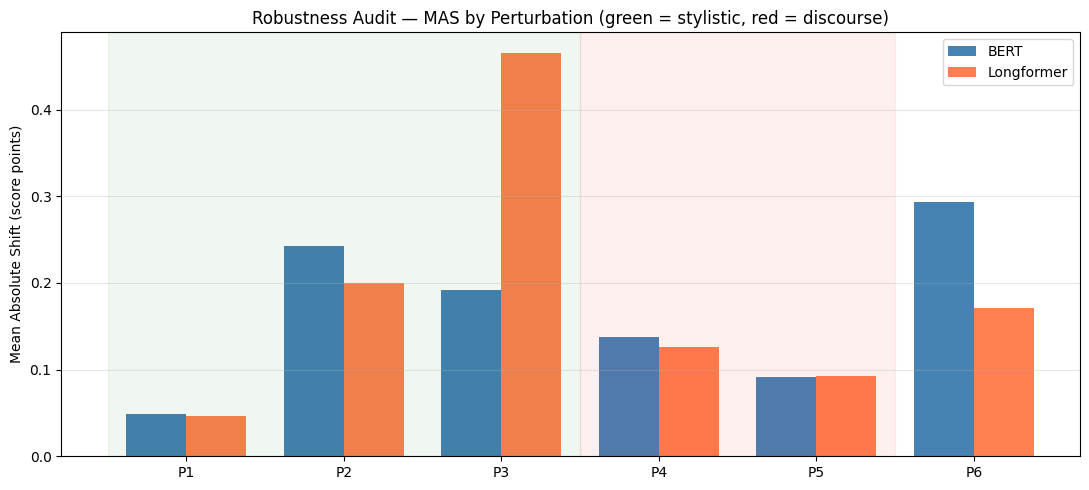

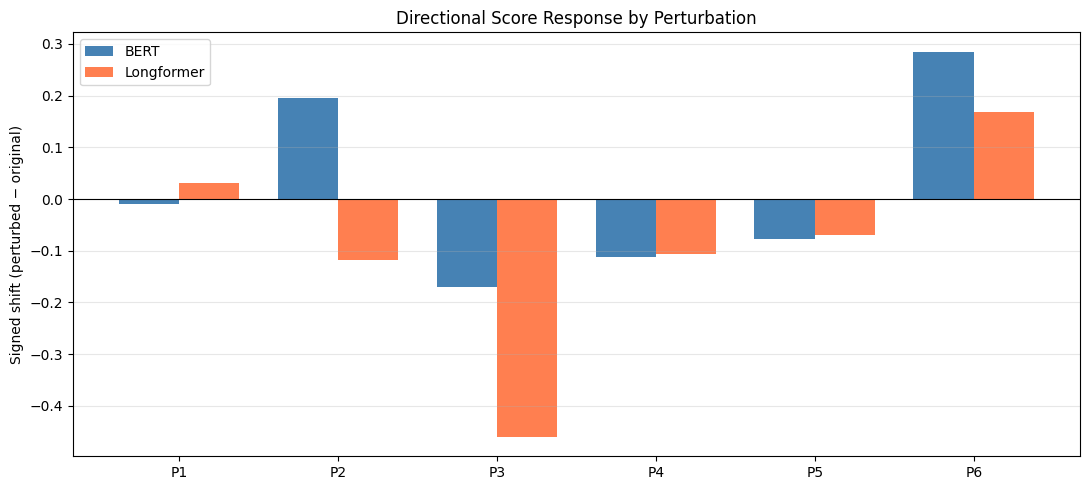

Saved: phase4_audit_results.csv, fig_audit_mas.png, fig_audit_signed.png


In [11]:
order = list(PERTURBATIONS.keys())
short = [p.split('_')[0] for p in order]

bert_mas = [bert_results.set_index('perturbation')['MAS'].get(p, np.nan) for p in order]
lf_mas   = [lf_results.set_index('perturbation')['MAS'].get(p, np.nan)   for p in order]

x = np.arange(len(order)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, bert_mas, w, label='BERT', color='steelblue')
ax.bar(x + w/2, lf_mas,   w, label='Longformer', color='coral')
ax.axvspan(-0.5, 2.5, alpha=0.06, color='green')   # stylistic
ax.axvspan(2.5, 4.5, alpha=0.06, color='red')      # discourse
ax.set_xticks(x); ax.set_xticklabels(short)
ax.set_ylabel('Mean Absolute Shift (score points)')
ax.set_title('Robustness Audit — MAS by Perturbation (green = stylistic, red = discourse)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('fig_audit_mas.png', dpi=150, bbox_inches='tight'); plt.show()

bert_sgn = [bert_results.set_index('perturbation')['signed_shift'].get(p, np.nan) for p in order]
lf_sgn   = [lf_results.set_index('perturbation')['signed_shift'].get(p, np.nan)   for p in order]
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, bert_sgn, w, label='BERT', color='steelblue')
ax.bar(x + w/2, lf_sgn,   w, label='Longformer', color='coral')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(short)
ax.set_ylabel('Signed shift (perturbed − original)')
ax.set_title('Directional Score Response by Perturbation')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('fig_audit_signed.png', dpi=150, bbox_inches='tight'); plt.show()

print("Saved: phase4_audit_results.csv, fig_audit_mas.png, fig_audit_signed.png")